# Gait Analysis

This notebook creates rollouts and performs and plots gait analysis on them

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# Change this to egl or glfw if available
os.environ["MUJOCO_GL"] = "egl"
import mediapy as media

from track_mjx.agent import checkpointing
from track_mjx.analysis import rollout, render, utils

import jax
from jax import numpy as jp
from pathlib import Path
from tqdm import tqdm
import numpy as np
import mujoco
from mujoco import mjx
import matplotlib.pyplot as plt
import jax.numpy as jnp
import functools
from brax.envs.base import Env
from track_mjx.environment.task.multi_clip_tracking import MultiClipTracking
from track_mjx.environment import wrappers
from typing import Callable, Dict
from omegaconf import DictConfig
from scipy import interpolate
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="deduperreload")

# Imitation Learning env setup

In [2]:
ckpt_path = '/home/mila/a/aidan.sirbu/scratch/track-mjx/model_checkpoints/250728_102037_742638'
ckpt = checkpointing.load_checkpoint_for_eval(ckpt_path, step=30)
cfg = ckpt["cfg"]

env = rollout.create_environment(cfg)
inference_fn = checkpointing.load_inference_fn(cfg, ckpt["policy"])

Loading checkpoint from /home/mila/a/aidan.sirbu/scratch/track-mjx/model_checkpoints/250728_102037_742638 at step 30


2025-08-04 10:41:11.924616: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.8 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Rescaling body tree with scale factor 0.9


## Generate rollout

### Parallel Rollouts

In [3]:
def create_rollout_generator(
    cfg: Dict | DictConfig,
    environment: Env,
    inference_fn: Callable,
):
    
    env = wrappers.RenderRolloutWrapperMulticlipTracking(environment)

    jit_inference_fn = jax.jit(inference_fn)
    jit_reset, jit_step = jax.jit(env.reset), jax.jit(env.step)

    clip_length = cfg["reference_config"].clip_length

    def generate_rollouts(clip_idx: int):
        """JAX-compatible rollout generation using jax.lax.scan."""
        rng = jax.random.PRNGKey(2)
        rng, reset_rng = jax.random.split(rng)
        reset_state = jit_reset(reset_rng, clip_idx=clip_idx)

        num_steps = env._steps_for_cur_frame * clip_length - 1

        def step_fn(carry, _):
            """Single step function for jax.lax.scan."""
            state, rng_key = carry
            act_rng, new_rng = jax.random.split(rng_key)
            ctrl, info = jit_inference_fn(state.obs, act_rng)
            next_state = jit_step(state, ctrl)
            
            # Return (new_carry, outputs)
            return (next_state, new_rng), (next_state, info)
        
        # Use jax.lax.scan instead of Python loop
        init_carry = (reset_state, rng)
        (final_state, final_rng), (states, network_infos) = jax.lax.scan(
            step_fn, init_carry, None, length=num_steps
        )
        
        # Prepend the initial state to get complete trajectory
        def prepend_state(init, trajectory):
            if trajectory.ndim == 0:  # Handle scalar values
                return trajectory
            return jnp.concatenate([init[None], trajectory])
        
        complete_rollout = jax.tree.map(prepend_state, reset_state, states)

        # Get reference trajectory
        ref_traj = env._get_reference_clip(reset_state.info)
        qposes_ref = jnp.repeat(
            jnp.hstack([ref_traj.position, ref_traj.quaternion, ref_traj.joints]),
            int(env._steps_for_cur_frame),
            axis=0,
        )
        
        return (complete_rollout, qposes_ref)

    return generate_rollouts

In [4]:
generate_rollouts = create_rollout_generator(cfg, env, inference_fn)

# Create a partial function with clip_length fixed
generate_rollouts_with_length = functools.partial(
    generate_rollouts
)

jit_vmap_generate_rollout = jax.jit(jax.vmap(generate_rollouts_with_length))

In [5]:
# All clips which contain walking behaviour
clip_idxs = jp.array([2, 8, 15]) #, 19, 22, 25, 30, 32, 33, 34, 35, 38, 41, 42, 43, 49, 51, 52, 54, 56, 58, 61, 67, 70, 73, 75, 76, 82, 83, 96, 97, 98, 102, 104, 105, 107, 109, 110, 111, 112, 116, 117, 122, 123, 124, 125, 129, 131, 139, 140, 143, 144, 145, 148, 149, 150, 152, 155, 156, 162, 163, 167, 169, 170, 171, 174, 176, 178, 179, 182, 184, 188, 189, 190, 191, 196, 197, 198, 201, 206, 209, 211, 212, 213, 215, 216, 219, 220, 224, 226, 230, 231, 232, 235, 238, 242, 250, 252, 253, 256, 257, 258, 263, 265, 266, 270, 272, 273, 277, 280, 281, 284, 287, 289, 293, 294, 295, 296, 297, 299, 300, 302, 305, 306, 307, 308, 309, 313, 315, 319, 326, 331, 333, 334, 335, 336, 337, 338, 344, 347, 348, 352, 353, 354, 358, 363, 364, 366, 367, 369, 370, 371, 372, 373, 374, 377, 378, 380, 381, 382, 386, 388, 389, 392, 393, 394, 395, 398, 399, 401, 403, 406, 408, 412, 416, 418, 419, 421, 426, 427, 432, 434, 436, 437, 438, 441, 442, 443, 445, 446, 447, 448, 451, 452, 453, 455, 458, 459, 463, 464, 470, 471, 472, 473, 475, 476, 478, 481, 482, 488, 489, 490, 491, 492, 494, 496, 497, 498, 499, 500, 501, 503, 504, 505, 508, 512, 514, 515, 516, 517, 520, 521, 522, 526, 530, 532, 533, 535, 538, 540, 541, 542, 544, 546, 547, 550, 553, 555, 559, 562, 563, 565, 567, 573, 574, 579, 583, 585, 586, 589, 590, 591, 594, 597, 599, 600, 604, 605, 608, 610, 611, 619, 620, 624, 625, 630, 635, 636, 638, 640, 641, 642, 644, 645, 647, 649, 650, 652, 657, 663, 664, 668, 674, 676, 679, 680, 682, 683, 686, 688, 689, 692, 694, 698, 701, 704, 705, 713, 714, 717, 718, 722, 723, 724, 725, 727, 731, 736, 737, 739, 742, 743, 744, 745, 746, 747, 748, 751, 752, 753, 758, 760, 761, 766, 767, 768, 769, 776, 778, 779, 784, 785, 786, 790, 791, 793, 796, 797, 798, 799, 800, 804, 806, 810, 814, 815, 816, 819, 821, 822, 825, 829, 833])
(jit_vmap_out, qposes_ref) = jit_vmap_generate_rollout(clip_idxs)

#### Rollout and Reference Joint Angles

In [13]:
qposes_ref[0].shape
for idx, el in enumerate(qposes_ref[0][0,:]):
    print(f"Element {idx}: {el}")

Element 0: -0.1381109207868576
Element 1: -0.018508857116103172
Element 2: 0.01597439870238304
Element 3: 0.9477411508560181
Element 4: 0.013704728335142136
Element 5: 0.08701761811971664
Element 6: 0.30663827061653137
Element 7: -0.3221839964389801
Element 8: -0.26410263776779175
Element 9: 0.02734055183827877
Element 10: -0.37486931681632996
Element 11: -0.20811773836612701
Element 12: -0.05138358846306801
Element 13: -0.11901634931564331
Element 14: -0.17501410841941833
Element 15: -0.09421029686927795
Element 16: -0.06164845451712608
Element 17: 0.05696077272295952
Element 18: 0.0
Element 19: -0.08395255357027054
Element 20: -0.06865871697664261
Element 21: -0.17476971447467804
Element 22: -0.04540552198886871
Element 23: -0.0024215367157012224
Element 24: 0.0
Element 25: 0.0
Element 26: 0.0
Element 27: 0.0
Element 28: 0.0
Element 29: 0.0
Element 30: 0.0
Element 31: 0.0
Element 32: 0.0
Element 33: 0.0
Element 34: 0.0
Element 35: 0.0
Element 36: 0.0
Element 37: 0.0
Element 38: 0.0
E

#### Get collision geoms -> Perform mapping -> Convert to contact barcode (swing/stance)

In [ ]:
collision_geoms_id = np.unique(jit_vmap_out.pipeline_state.contact.geom2[2,:,:])
xml_path = "/home/mila/a/aidan.sirbu/track-mjx/track_mjx/environment/walker/assets/rodent/rodent.xml"
mj_model = mujoco.MjModel.from_xml_path(xml_path)

collision_names = [
    mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_GEOM, i)
    for i in collision_geoms_id
]

print(f'Collision names: {collision_names}')

labels = ["FL", "FR", "HL", "HR"]

mapping = {val: i // 4 for i, val in enumerate(collision_geoms_id)}

# Process each rollout separately
all_contact_barcodes = []

for batch_idx in range(len(jit_vmap_out.pipeline_state.qpos)):  # Loop over batch
    # Extract single rollout from batch
    single_pipeline_state = jax.tree.map(lambda x: x[batch_idx], jit_vmap_out.pipeline_state)
    
    # Convert to mujoco data
    ds_single = mjx.get_data(env.sys.mj_model, single_pipeline_state)
    
    # Process contacts for this rollout
    contacts_barcode = []
    for d in ds_single:
        code = np.zeros(4)
        for i in d.contact.geom2:
            if i in mapping:  # Add safety check
                code[mapping[i]] = 1
        contacts_barcode.append(code)
    
    contacts_barcode = np.array(contacts_barcode).T
    all_contact_barcodes.append(contacts_barcode)

Collision names: ['foot_L_collision', 'toe_L0_collision', 'toe_L1_collision', 'toe_L2_collision', 'foot_R_collision', 'toe_R0_collision', 'toe_R1_collision', 'toe_R2_collision', 'hand_L_collision', 'finger_L0_collision', 'finger_L1_collision', 'finger_L2_collision', 'hand_R_collision', 'finger_R0_collision', 'finger_R1_collision', 'finger_R2_collision']


In [7]:
# You already have the MuJoCo model loaded:
xml_path = "/home/mila/a/aidan.sirbu/track-mjx/track_mjx/environment/walker/assets/rodent/rodent.xml"
mj_model = mujoco.MjModel.from_xml_path(xml_path)

# Extract joint names
joint_names = []
for i in range(mj_model.njnt):
    joint_name = mujoco.mj_id2name(mj_model, mujoco.mjtObj.mjOBJ_JOINT, i)
    joint_names.append(joint_name)

print(f"Number of joints: {len(joint_names)}")
print(f"Joint names: {joint_names}")

Number of joints: 68
Joint names: ['root', 'vertebra_1_extend', 'vertebra_2_bend', 'vertebra_3_twist', 'vertebra_4_extend', 'vertebra_5_bend', 'vertebra_6_twist', 'hip_L_supinate', 'hip_L_abduct', 'hip_L_extend', 'knee_L', 'ankle_L', 'toe_L', 'hip_R_supinate', 'hip_R_abduct', 'hip_R_extend', 'knee_R', 'ankle_R', 'toe_R', 'vertebra_C1_extend', 'vertebra_C1_bend', 'vertebra_C2_extend', 'vertebra_C2_bend', 'vertebra_C3_extend', 'vertebra_C3_bend', 'vertebra_C4_extend', 'vertebra_C4_bend', 'vertebra_C5_extend', 'vertebra_C5_bend', 'vertebra_C6_extend', 'vertebra_C6_bend', 'vertebra_C7_extend', 'vertebra_C9_bend', 'vertebra_C11_extend', 'vertebra_C13_bend', 'vertebra_C15_extend', 'vertebra_C17_bend', 'vertebra_C19_extend', 'vertebra_C21_bend', 'vertebra_C23_extend', 'vertebra_C25_bend', 'vertebra_C27_extend', 'vertebra_C29_bend', 'vertebra_cervical_5_extend', 'vertebra_cervical_4_bend', 'vertebra_cervical_3_twist', 'vertebra_cervical_2_extend', 'vertebra_cervical_1_bend', 'vertebra_axis_twi

#### Joint names

In [11]:
# Create mapping of joint names to qpos indices
qpos_joint_mapping = {}
qpos_offset = 7  # Skip root position (3) + root quaternion (4)

for i, joint_name in enumerate(joint_names):
    qpos_joint_mapping[joint_name] = qpos_offset + i

print("Joint name to qpos index mapping:")
for joint_name, qpos_idx in qpos_joint_mapping.items():
    print(f"  {joint_name}: qpos[{qpos_idx}]")

Joint name to qpos index mapping:
  root: qpos[7]
  vertebra_1_extend: qpos[8]
  vertebra_2_bend: qpos[9]
  vertebra_3_twist: qpos[10]
  vertebra_4_extend: qpos[11]
  vertebra_5_bend: qpos[12]
  vertebra_6_twist: qpos[13]
  hip_L_supinate: qpos[14]
  hip_L_abduct: qpos[15]
  hip_L_extend: qpos[16]
  knee_L: qpos[17]
  ankle_L: qpos[18]
  toe_L: qpos[19]
  hip_R_supinate: qpos[20]
  hip_R_abduct: qpos[21]
  hip_R_extend: qpos[22]
  knee_R: qpos[23]
  ankle_R: qpos[24]
  toe_R: qpos[25]
  vertebra_C1_extend: qpos[26]
  vertebra_C1_bend: qpos[27]
  vertebra_C2_extend: qpos[28]
  vertebra_C2_bend: qpos[29]
  vertebra_C3_extend: qpos[30]
  vertebra_C3_bend: qpos[31]
  vertebra_C4_extend: qpos[32]
  vertebra_C4_bend: qpos[33]
  vertebra_C5_extend: qpos[34]
  vertebra_C5_bend: qpos[35]
  vertebra_C6_extend: qpos[36]
  vertebra_C6_bend: qpos[37]
  vertebra_C7_extend: qpos[38]
  vertebra_C9_bend: qpos[39]
  vertebra_C11_extend: qpos[40]
  vertebra_C13_bend: qpos[41]
  vertebra_C15_extend: qpos[

## Gait Diagram (Swing/Stance)

In [15]:
def plot_gait_diagram(contact_data, labels=None, title="Gait Diagram", figsize=(15, 8),
                     tick_fontsize=10, label_fontsize=12, legend_fontsize=11, title_fontsize=14):
    """
    Plot swing and stance phases for limbs over time.
    
    Parameters:
    - contact_data: numpy array of shape (4, time) where 1 = stance, 0 = swing
    - labels: list of 4 strings for limb labels (default: ["FL", "FR", "HL", "HR"])
    - title: plot title
    - figsize: figure size tuple
    - tick_fontsize: font size for axis tick labels (default: 10)
    - label_fontsize: font size for x and y axis labels (default: 12)
    - legend_fontsize: font size for legend (default: 11)
    - title_fontsize: font size for plot title (default: 14)
    """
    if labels is None:
        labels = ["FL", "FR", "HL", "HR"]
    
    num_limbs, num_timesteps = contact_data.shape
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Colors for stance (contact) and swing phases
    stance_color = '#2E8B57'  # Sea green
    swing_color = '#F0F0F0'   # Light gray
    
    # Plot each limb's gait pattern
    for i, limb_label in enumerate(labels):
        y_pos = i
        
        # Create bars for stance phases
        for t in range(num_timesteps):
            if contact_data[i, t] == 1:  # Stance phase
                ax.barh(y_pos, 1, left=t, height=0.8, 
                       color=stance_color, alpha=0.8, 
                       edgecolor='black', linewidth=0.5)
            else:  # Swing phase
                ax.barh(y_pos, 1, left=t, height=0.8, 
                       color=swing_color, alpha=0.8, 
                       edgecolor='black', linewidth=0.5)
    
    # Customize the plot
    ax.set_yticks(range(num_limbs))
    ax.set_yticklabels(labels)
    ax.set_xlabel('Time Steps', fontsize=label_fontsize)
    ax.set_ylabel('Limbs', fontsize=label_fontsize)
    ax.set_title(title, fontsize=title_fontsize)
    
    # Set tick font sizes
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    
    # Add legend
    stance_patch = plt.Rectangle((0, 0), 1, 1, facecolor=stance_color, alpha=0.8)
    swing_patch = plt.Rectangle((0, 0), 1, 1, facecolor=swing_color, alpha=0.8)
    ax.legend([stance_patch, swing_patch], ['Stance', 'Swing'], loc='upper right', fontsize=legend_fontsize)
    
    # Set limits and grid
    ax.set_xlim(0, num_timesteps)
    ax.set_ylim(-0.5, num_limbs - 0.5)
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()

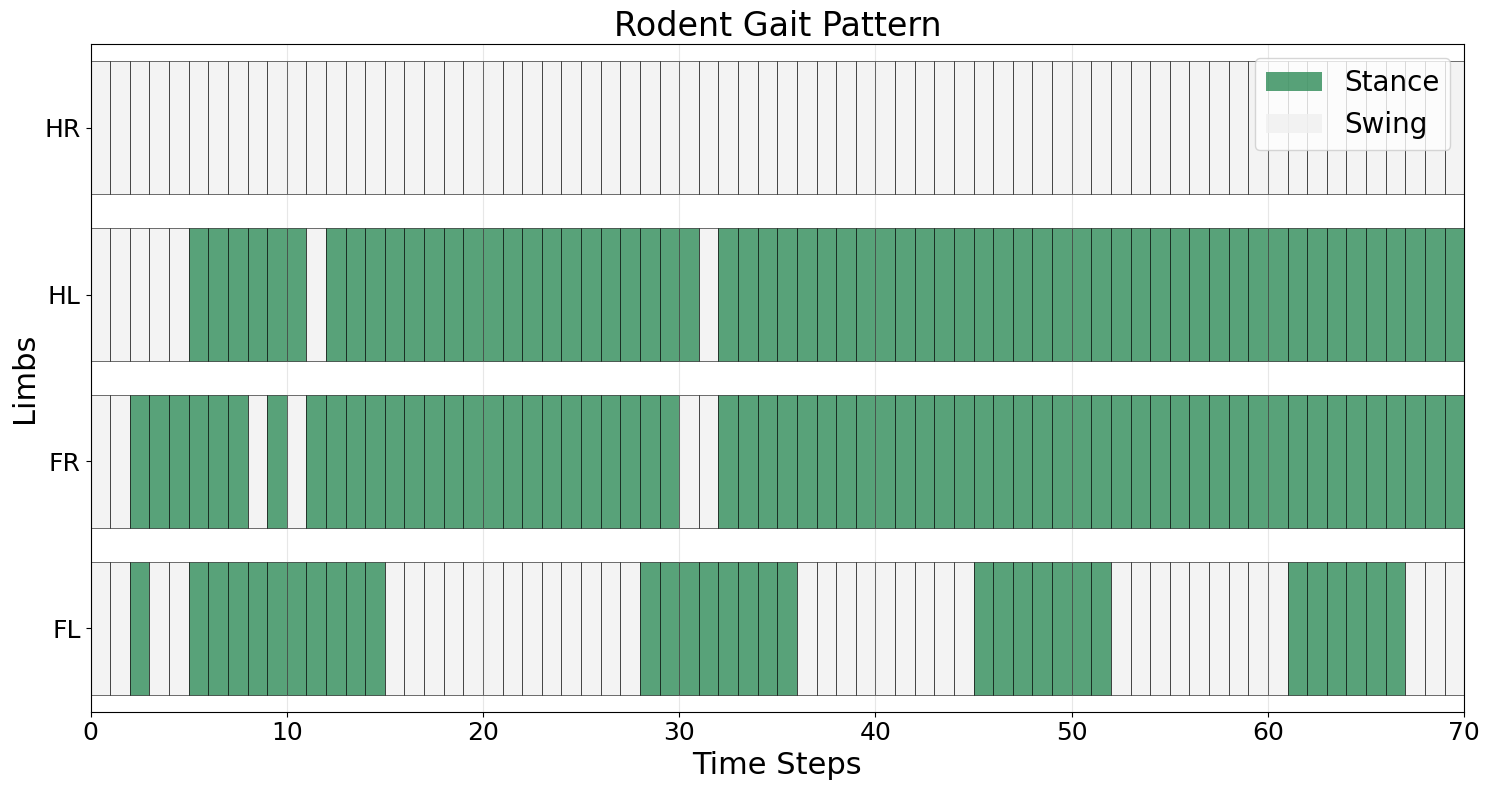

In [16]:
plot_gait_diagram(
    all_contact_barcodes[0][:,0:70], 
    labels=["FL", "FR", "HL", "HR"], 
    title="Rodent Gait Pattern",
    tick_fontsize=18,
    label_fontsize=22, 
    legend_fontsize=20,
    title_fontsize=24
)

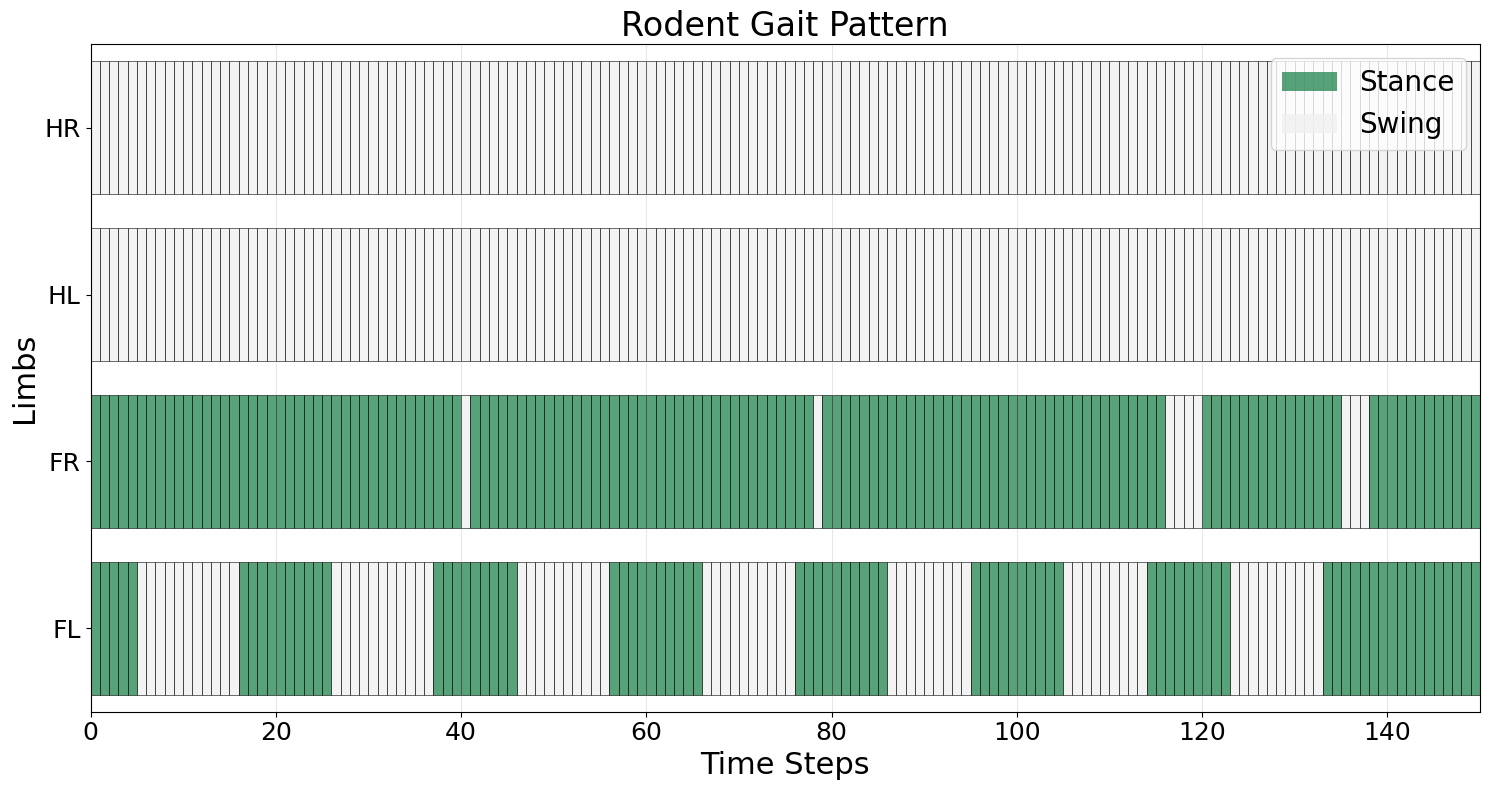

In [11]:
plot_gait_diagram(
    all_contact_barcodes[1][:,50:200], 
    labels=["FL", "FR", "HL", "HR"], 
    title="Rodent Gait Pattern",
    tick_fontsize=18,
    label_fontsize=22, 
    legend_fontsize=20,
    title_fontsize=24
)

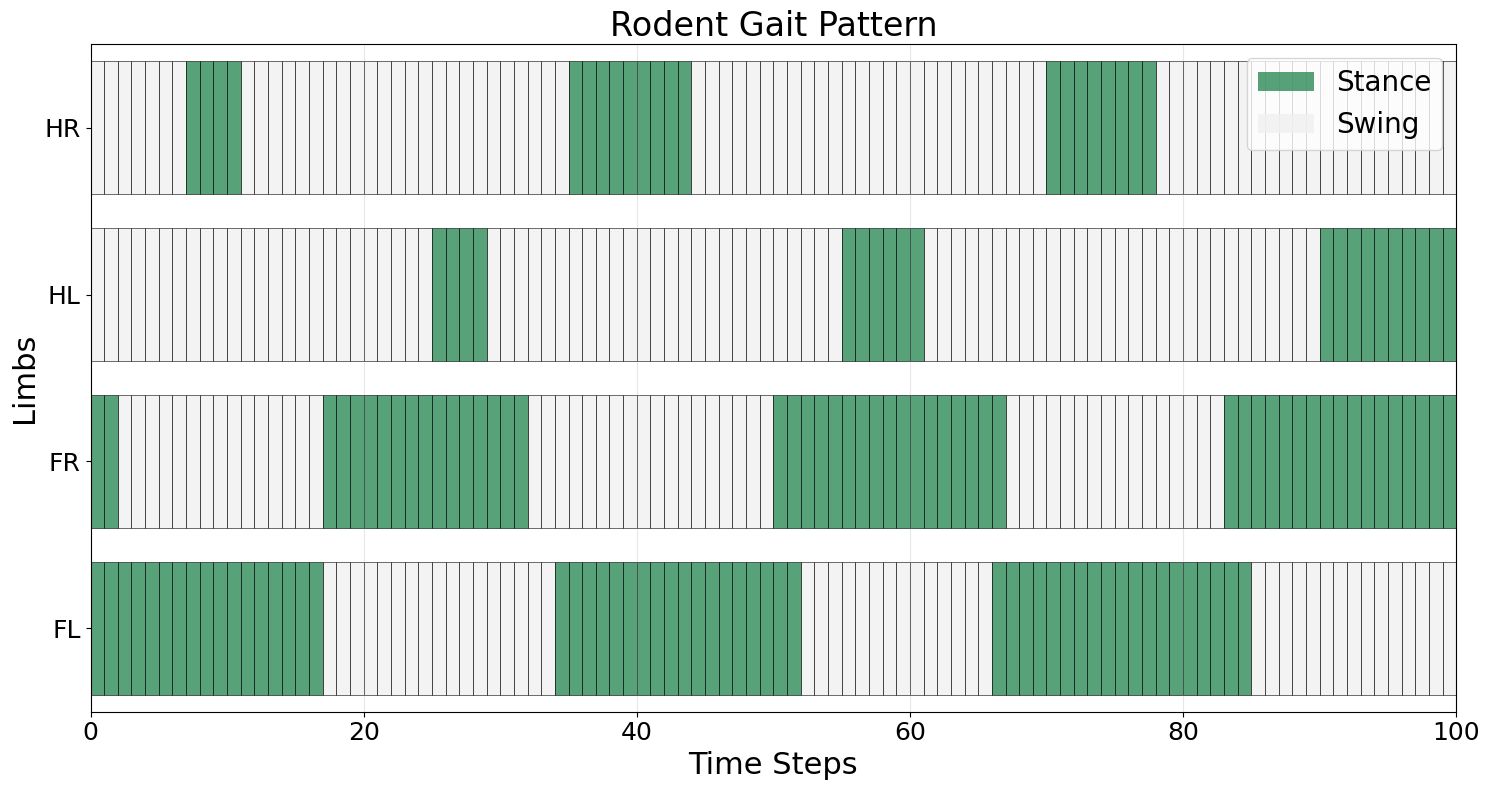

In [12]:
plot_gait_diagram(
    all_contact_barcodes[2][:,170:270], 
    labels=["FL", "FR", "HL", "HR"], 
    title="Rodent Gait Pattern",
    tick_fontsize=18,
    label_fontsize=22, 
    legend_fontsize=20,
    title_fontsize=24
)

## Gait Cycle Analysis

In [12]:
def analyze_gait_cycles_across_rollouts(
    all_contact_barcodes, 
    jit_vmap_out, 
    qposes_ref, 
    time_windows, 
    qpos_indices, 
    figsize=(12, 8),
    rollout_color='blue',
    reference_color='red',
    tick_fontsize=10,
    label_fontsize=12,
    legend_fontsize=11,
    title_fontsize=14,
    plot_titles=None
):
    """
    Analyze joint angles across gait cycles for multiple rollouts.
    
    Args:
        all_contact_barcodes: List of contact barcodes, one per rollout (shape: [rollout][4, time])
        jit_vmap_out: Vectorized rollout output with pipeline_state.qpos
        qposes_ref: Reference joint positions for all rollouts
        time_windows: List of (start, end) tuples defining analysis windows for each rollout
        qpos_indices: List of qpos indices to analyze (corresponding to qpos features)
        figsize: Figure size for each plot
        rollout_color: Color for rollout line and shading (default: 'blue')
        reference_color: Color for reference line and shading (default: 'red')
        tick_fontsize: Font size for axis tick labels (default: 10)
        label_fontsize: Font size for x and y axis labels (default: 12)
        legend_fontsize: Font size for legend (default: 11)
        title_fontsize: Font size for plot title (default: 14)
        plot_titles: List of strings for plot titles, one per joint (default: None)
        
    Returns:
        dict: Analysis results containing gait cycle data and statistics
    """
    
    # FR limb is index 1 in the contact barcode (FL=0, FR=1, HL=2, HR=3)
    FR_INDEX = 1
    
    def find_gait_cycles(contact_barcode, start_time, end_time):
        """Find gait cycles based on FR stance phases within time window."""
        fr_contacts = contact_barcode[FR_INDEX, start_time:end_time]
        
        # Find stance onsets (transitions from 0 to 1)
        stance_onsets = []
        for i in range(1, len(fr_contacts)):
            if fr_contacts[i-1] == 0 and fr_contacts[i] == 1:
                stance_onsets.append(start_time + i)
        
        # Create gait cycles from consecutive stance onsets
        gait_cycles = []
        for i in range(len(stance_onsets) - 1):
            cycle_start = stance_onsets[i]
            cycle_end = stance_onsets[i + 1]
            gait_cycles.append((cycle_start, cycle_end))
        
        return gait_cycles
    
    def normalize_to_gait_percentage(data, cycle_length):
        """Interpolate data to standard 100-point gait cycle percentage."""
        if cycle_length <= 1:
            return np.array([data[0]] * 100) if len(data) > 0 else np.zeros(100)
        
        original_time = np.linspace(0, 100, cycle_length)
        target_time = np.linspace(0, 100, 100)
        
        # Use linear interpolation to normalize to 100 points
        interp_func = interpolate.interp1d(original_time, data, kind='cubic', 
                                         bounds_error=False, fill_value='extrapolate')
        return interp_func(target_time)
    
    # Storage for all gait cycle data
    all_gait_data = {qpos_idx: {'rollout': [], 'reference': []} for qpos_idx in qpos_indices}

    print(f"Analyzing {len(time_windows)} rollouts...")
    
    # Process each rollout
    for rollout_idx, (start_time, end_time) in enumerate(time_windows):
        print(f"Processing rollout {rollout_idx + 1}/{len(time_windows)} "
              f"(time window: {start_time}-{end_time})")
        
        # Get contact barcode for this rollout
        contact_barcode = all_contact_barcodes[rollout_idx]
        
        # Find gait cycles in this rollout
        gait_cycles = find_gait_cycles(contact_barcode, start_time, end_time)
        print(f"  Found {len(gait_cycles)} gait cycles")
        
        if len(gait_cycles) == 0:
            print(f"  Warning: No gait cycles found in rollout {rollout_idx}")
            continue
        
        # Extract joint data for this rollout
        rollout_qpos = jit_vmap_out.pipeline_state.qpos[rollout_idx]  # Shape: (time, features)
        reference_qpos = qposes_ref[rollout_idx]  # Shape: (time, features)
        
        # Process each gait cycle
        for cycle_start, cycle_end in gait_cycles:
            cycle_length = cycle_end - cycle_start
            
            # Extract joint angles for each requested joint
            for qpos_idx in qpos_indices:
                # Extract rollout joint data for this cycle
                rollout_joint = rollout_qpos[cycle_start:cycle_end, qpos_idx]
                reference_joint = reference_qpos[cycle_start:cycle_end, qpos_idx]

                # Normalize to gait percentage (0-100%)
                rollout_normalized = normalize_to_gait_percentage(rollout_joint, cycle_length)
                reference_normalized = normalize_to_gait_percentage(reference_joint, cycle_length)
                
                # Store normalized data
                all_gait_data[qpos_idx]['rollout'].append(rollout_normalized)
                all_gait_data[qpos_idx]['reference'].append(reference_normalized)
    
    # Create plots for each joint
    results = {}

    for plot_idx, qpos_idx in enumerate(qpos_indices):
        print(f"\nGenerating plot for qpos {qpos_idx}")

        rollout_cycles = np.array(all_gait_data[qpos_idx]['rollout'])
        reference_cycles = np.array(all_gait_data[qpos_idx]['reference'])

        if len(rollout_cycles) == 0:
            print(f"  Warning: No data found for qpos {qpos_idx}")
            continue
        
        # Calculate statistics
        rollout_mean = np.mean(rollout_cycles, axis=0)
        rollout_std = np.std(rollout_cycles, axis=0)
        reference_mean = np.mean(reference_cycles, axis=0)
        reference_std = np.std(reference_cycles, axis=0)
        
        # Store results
        results[qpos_idx] = {
            'rollout_mean': rollout_mean,
            'rollout_std': rollout_std,
            'reference_mean': reference_mean,
            'reference_std': reference_std,
            'n_cycles': len(rollout_cycles),
            'raw_cycles': {
                'rollout': rollout_cycles,
                'reference': reference_cycles
            }
        }
        
        # Create plot
        fig, ax = plt.subplots(figsize=figsize)
        
        gait_percentage = np.linspace(0, 100, 100)
        
        # Plot rollout data (solid line)
        ax.plot(gait_percentage, rollout_mean, '--', color=rollout_color, linewidth=4, 
                label='Rollout', alpha=0.8)
        ax.fill_between(gait_percentage, 
                       rollout_mean - rollout_std, 
                       rollout_mean + rollout_std, 
                       color=rollout_color, alpha=0.2)
        
        # Plot reference data (dashed line)
        ax.plot(gait_percentage, reference_mean, '-', color=reference_color, linewidth=4, 
                label='Reference', alpha=0.8)
        ax.fill_between(gait_percentage, 
                       reference_mean - reference_std, 
                       reference_mean + reference_std, 
                       color=reference_color, alpha=0.2)
        
        # Determine plot title
        if plot_titles is not None and plot_idx < len(plot_titles):
            plot_title = plot_titles[plot_idx]
        else:
            plot_title = f'Qpos {qpos_idx} - Gait Cycle Analysis\n({len(rollout_cycles)} cycles from {len(time_windows)} rollouts)'

        # Customize plot with custom font sizes
        ax.set_xlabel('Gait Cycle (%)', fontsize=label_fontsize)
        ax.set_ylabel('Joint Angle (rad)', fontsize=label_fontsize)
        ax.set_title(plot_title, fontsize=title_fontsize)
        ax.legend(fontsize=legend_fontsize)
        # ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 100)
        
        # Set tick font sizes
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        
        # Add cycle markers at key gait events (optional)
        ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(x=100, color='gray', linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()

        print(f"  Qpos {qpos_idx}: {len(rollout_cycles)} gait cycles analyzed")
        print(f"  Rollout mean range: [{rollout_mean.min():.3f}, {rollout_mean.max():.3f}]")
        print(f"  Reference mean range: [{reference_mean.min():.3f}, {reference_mean.max():.3f}]")

    print(f"\nAnalysis complete! Processed {sum(len(all_gait_data[j]['rollout']) for j in qpos_indices)} total gait cycles")

    return results

In [13]:
time_windows = [(0,70), (50,200), (170,270)]
qpos_indices = [13,14,15,16,17,19,20,21,22,23]
plot_titles = [
    "Left Hip Supinate"
    "Left Hip Abduction",
    "Left Hip Extension",
    "Left Knee",
    "Left Ankle",
    "Right Hip Supinate",
    "Right Hip Abduction",
    "Right Hip Extension",
    "Right Knee",
    "Right Ankle"
]

results = analyze_gait_cycles_across_rollouts(
    all_contact_barcodes, jit_vmap_out, qposes_ref, 
    time_windows, qpos_indices,
    rollout_color='#2E86AB',
    reference_color='#A23B72',
    tick_fontsize=18,
    label_fontsize=22,
    legend_fontsize=20,
    title_fontsize=24,
    plot_titles=plot_titles
)

Analyzing 3 rollouts...
Processing rollout 1/3 (time window: 0-70)
  Found 3 gait cycles


ValueError: The number of derivatives at boundaries does not match: expected 2, got 0+0

In [10]:
time_windows = [(0,70), (50,200), (170,270)]
joint_indices = [62,63,64,65]
plot_titles = [
    "Left Shoulder",
    "Left Shoulder Supinate",
    "Left Elbow",
    "Left Wrist",
]

results = analyze_gait_cycles_across_rollouts(
    all_contact_barcodes, jit_vmap_out, qposes_ref, 
    time_windows, joint_indices,
    rollout_color='#2E86AB',
    reference_color='#A23B72',
    tick_fontsize=18,
    label_fontsize=22,
    legend_fontsize=20,
    title_fontsize=24,
    plot_titles=plot_titles
)

Analyzing 3 rollouts...
Processing rollout 1/3 (time window: 0-70)
  Found 3 gait cycles


ValueError: The number of derivatives at boundaries does not match: expected 2, got 0+0

# Rendering

In [10]:
def render_and_save_all_videos(vmap_rollouts, save_dir, clip_indices=None, render_every=1, 
                              height=480, width=640, camera="close_profile"):
    """
    Memory-efficient rendering: processes one video at a time to avoid memory issues.
    
    Args:
        vmap_rollouts: Output from jit_vmap_generate_rollout (batch of rollouts)
        save_dir: Directory to save videos (will be created if doesn't exist)
        clip_indices: Array of clip indices corresponding to each rollout (uses global clip_idxs if None)
        render_every: Skip frames for faster rendering (2 = every other frame)
        height: Video height in pixels
        width: Video width in pixels  
        camera: Camera name for rendering
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    
    # Use global clip_idxs if not provided
    if clip_indices is None:
        clip_indices = clip_idxs
    
    # Get batch size from the rollout data
    batch_size = len(vmap_rollouts.pipeline_state.qpos)
    fps = 1.0 / env.dt / render_every
    
    print(f"Rendering and saving {batch_size} videos to: {save_dir}")
    print(f"Video settings: {height}x{width} @ {fps:.1f} fps (render_every={render_every})")
    print("-" * 60)
    
    for batch_idx in range(batch_size):
        clip_idx = clip_indices[batch_idx]
        video_filename = f"clip_{clip_idx:04d}_rollout.mp4"
        video_path = save_dir / video_filename
        
        print(f"[{batch_idx+1:3d}/{batch_size}] Processing clip {clip_idx:4d} → {video_filename}")
        
        try:
            # Extract single rollout from batch (shape: batch, time, ...)
            single_rollout = jax.tree.map(lambda x: x[batch_idx], vmap_rollouts)
            
            # Get trajectory length and create sampling indices
            trajectory_length = len(single_rollout.pipeline_state.qpos)
            sampled_indices = range(0, trajectory_length, render_every)
            
            # Create render states for each timestep
            render_states = []
            for t_idx in sampled_indices:
                # Extract state at timestep t_idx
                state_t = jax.tree.map(lambda x: x[t_idx], single_rollout)
                
                # Create render state object
                render_state = type('RenderState', (), {
                    'q': state_t.pipeline_state.qpos,
                    'qd': state_t.pipeline_state.qvel,
                    'pipeline_state': state_t.pipeline_state
                })()
                render_states.append(render_state)
            
            # Render the trajectory
            frames = env.render(
                render_states,
                camera=camera,
                height=height,
                width=width,
            )
            
            # Save video to disk
            media.write_video(str(video_path), frames, fps=fps)
            
            print(f"           ✓ Saved {len(frames)} frames ({len(frames)/fps:.1f}s duration)")
            
            # Clear frames from memory
            del frames, render_states, single_rollout
            
        except Exception as e:
            print(f"           ✗ Error processing clip {clip_idx}: {e}")
            continue
    
    print("-" * 60)
    print(f"✓ Completed! All videos saved to: {save_dir}")

In [12]:
def render_videos_from_vmap_output(vmap_rollouts, num_videos=None, video_indices=None):
    """
    Render videos from vectorized rollout output.
    
    Args:
        vmap_rollouts: Output from jit_vmap_generate_rollout (batch of rollouts)
        num_videos: Number of videos to render (if video_indices not specified)
        video_indices: Specific indices of rollouts to render (overrides num_videos)
    
    Returns:
        List of (frames, fps) tuples for each rendered video
    """
    # Determine which rollouts to render
    if video_indices is None:
        total_rollouts = len(vmap_rollouts.obs) if hasattr(vmap_rollouts, 'obs') else len(jit_vmap_out.pipeline_state.qpos)
        if num_videos is not None:
            video_indices = list(range(min(num_videos, total_rollouts)))
        else:
            video_indices = list(range(total_rollouts))
    
    
    fps = 1.0 / env.dt
    rendered_videos = []
    
    print(f"Rendering {len(video_indices)} videos from clips: {[clip_idxs[i] for i in video_indices]}")
    
    for i, rollout_idx in enumerate(video_indices):
        print(f"Rendering video {i+1}/{len(video_indices)} (clip_idx={clip_idxs[rollout_idx]})...")
        
        # Extract single rollout from batch
        # Note: vmap_rollouts has shape (batch, time, ...) so we index the first dimension
        single_rollout_states = jax.tree.map(lambda x: x[rollout_idx], vmap_rollouts)
        
        # Convert to list for rendering (subsample if needed)
        trajectory_length = len(single_rollout_states.pipeline_state.qpos)
        sampled_indices = range(0, trajectory_length)
        
        # Create render states for each timestep
        render_states = []
        for t_idx in sampled_indices:
            # Extract state at timestep t_idx
            state_t = jax.tree.map(lambda x: x[t_idx], single_rollout_states)
            
            # Create render state object
            render_state = type('RenderState', (), {
                'q': state_t.pipeline_state.qpos,
                'qd': state_t.pipeline_state.qvel,
                'pipeline_state': state_t.pipeline_state
            })()
            render_states.append(render_state)
        
        # Render the trajectory
        frames = env.render(
            render_states,
            camera="close_profile",
            height=480,
            width=640,
        )
        
        rendered_videos.append((frames, fps))
        print(f"  → Generated {len(frames)} frames at {fps:.1f} fps")
    
    return rendered_videos

In [13]:
rendered_videos = render_videos_from_vmap_output(jit_vmap_out, num_videos=None)

# Display the videos
for i, (frames, fps) in enumerate(rendered_videos):
    clip_idx = clip_idxs[i]
    print(f"\n=== Video {i+1}: Clip {clip_idx} ===")
    media.show_video(frames, fps=fps, loop=False)

Rendering 3 videos from clips: [Array(2, dtype=int32), Array(8, dtype=int32), Array(15, dtype=int32)]
Rendering video 1/3 (clip_idx=2)...
  → Generated 500 frames at 100.0 fps
Rendering video 2/3 (clip_idx=8)...
  → Generated 500 frames at 100.0 fps
Rendering video 3/3 (clip_idx=15)...
  → Generated 500 frames at 100.0 fps

=== Video 1: Clip 2 ===


This browser does not support the video tag.



=== Video 2: Clip 8 ===


This browser does not support the video tag.



=== Video 3: Clip 15 ===


This browser does not support the video tag.


In [20]:
rendered_videos = render_videos_from_vmap_output(jit_vmap_out, num_videos=3)

# Display the videos
for i, (frames, fps) in enumerate(rendered_videos):
    clip_idx = clip_idxs[i]
    print(f"\n=== Video {i+1}: Clip {clip_idx} ===")
    media.show_video(frames, fps=fps, loop=False)

Rendering 3 videos from clips: [Array(2, dtype=int32), Array(8, dtype=int32), Array(15, dtype=int32)]
Rendering video 1/3 (clip_idx=2)...
  → Generated 500 frames at 100.0 fps
Rendering video 2/3 (clip_idx=8)...
  → Generated 500 frames at 100.0 fps
Rendering video 3/3 (clip_idx=15)...
  → Generated 500 frames at 100.0 fps

=== Video 1: Clip 2 ===


This browser does not support the video tag.



=== Video 2: Clip 8 ===


This browser does not support the video tag.



=== Video 3: Clip 15 ===


This browser does not support the video tag.


In [11]:
# Example: Render and save all videos from your batch
save_directory = "/home/mila/a/aidan.sirbu/scratch/track-mjx/renderings"

# This will process each video one at a time to avoid memory issues
render_and_save_all_videos(
    jit_vmap_out, 
    save_dir=save_directory,
    render_every=1,  # Skip frames for smaller file sizes and faster processing
    height=360,      # Smaller resolution for faster processing
    width=480
)

print(f"All videos saved to: {save_directory}")

Rendering and saving 363 videos to: /home/mila/a/aidan.sirbu/scratch/track-mjx/renderings
Video settings: 360x480 @ 100.0 fps (render_every=1)
------------------------------------------------------------
[  1/363] Processing clip    2 → clip_0002_rollout.mp4
           ✓ Saved 501 frames (5.0s duration)
[  2/363] Processing clip    8 → clip_0008_rollout.mp4
           ✓ Saved 501 frames (5.0s duration)
[  2/363] Processing clip    8 → clip_0008_rollout.mp4
           ✓ Saved 501 frames (5.0s duration)
[  3/363] Processing clip   15 → clip_0015_rollout.mp4
           ✓ Saved 501 frames (5.0s duration)
[  3/363] Processing clip   15 → clip_0015_rollout.mp4
           ✓ Saved 501 frames (5.0s duration)
[  4/363] Processing clip   19 → clip_0019_rollout.mp4
           ✓ Saved 501 frames (5.0s duration)
[  4/363] Processing clip   19 → clip_0019_rollout.mp4
           ✓ Saved 501 frames (5.0s duration)
[  5/363] Processing clip   22 → clip_0022_rollout.mp4
           ✓ Saved 501 frames (5.0

KeyboardInterrupt: 